# **Overfitting e regularização**

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

<hr>

## Overfitting

Nessa aula vamos aprender a ajustar modelos e verificar quando ocorre overfitting. Vamos fazer o ajuste de um conjunto de pontos a partir de um polinômio, usando um método de regressão linear.

Vamos gerar os dados a partir uma função definida:

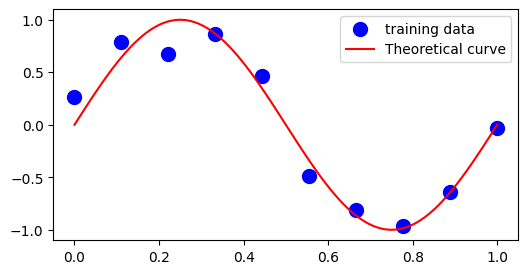

In [56]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(10)

#função para gerar os dados
def function(x):
    y = np.sin(2 * np.pi * x)
    #y = np.cos(2 * np.pi * x)
    #y = x**4 + x**9
    return y

# training set
N_train = 10
sigma = 0.2
x_train= np.linspace(0, 1,N_train)
y_train = function(x_train) + np.random.normal(0,sigma, N_train)
X_train = x_train.reshape(len(x_train), 1)

fig = plt.figure(figsize=(6, 3))
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b",
            s=100, label="training data")

# test set
N_test = 20
X_test=np.linspace(0, 1,N_test)
y_test = function(X_test) +  np.random.normal(0,sigma, N_test)
X_test = X_test.reshape(len(X_test), 1)

# Curva teorica
xt = np.linspace(0,1,100)
yt = function(xt)
plt.plot(xt,yt, '-r',  label="Theoretical curve")
plt.legend(fontsize=10)
plt.show(True)

Os dados que temos acesso são os pontos em azul. A curva em vermelho é desconhecida, representando o modelo gerador dos dados.

Vamos fazer o ajuste usando um polinômio de grau $M$.
$$
f(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_M x^M
$$
Inicialmente, vamos considerar $M=1$, ou seja, um ajuste linear.
$$
f(x,\theta) = \theta_0 + \theta_1 x
$$

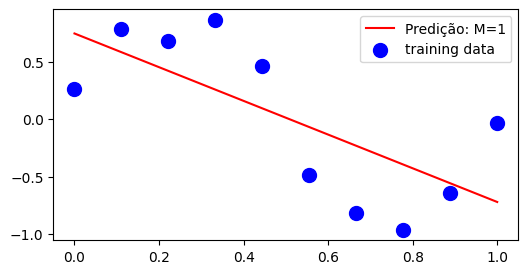

In [57]:
from sklearn import linear_model

# usa regressão linear para ajustar o modelo
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

# preve os valores de y a partir de x
xplot = np.linspace(0,1,200)
Xplot = xplot.reshape(len(xplot), 1)
Y_pred = model.predict(Xplot)

# mostra os resultados
fig = plt.figure(figsize=(6, 3))
plt.plot(Xplot, Y_pred, label='Predição: M=1', color = 'red')
plt.scatter(X_train, y_train, facecolor="blue", edgecolor="b", s=100,
            label="training data")
plt.legend(fontsize=10)
plt.show(True)

Notamos que, nesse caso, o ajuste é muito ruim, pois os dados foram gerados a partir de uma função não-linear. Esse fenômeno é chamado **underfitting** e ocorre quando o viíes (bias) é grande.

Vamos fazer o ajuste usando um polinômio de grau $M=3$.
$$
f(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 +  \theta_3 x^3
$$
Veja sobre a função para gerar o polinômio no link: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

In [58]:
from sklearn.preprocessing import PolynomialFeatures
# Define a matriz de atributos
poly3 = PolynomialFeatures(degree=3)
X = poly3.fit_transform(X_train)
print('X^0             X^1          Xˆ2         Xˆ3')
print(X)
model = linear_model.LinearRegression()
model.fit(X,y_train)
# graficamos a curva obtida a partir da predição
xplot = np.linspace(0,1,200)
xplot = xplot.reshape(len(xplot), 1)
Xplot=poly3.fit_transform(xplot)

X^0             X^1          Xˆ2         Xˆ3
[[1.         0.         0.         0.        ]
 [1.         0.11111111 0.01234568 0.00137174]
 [1.         0.22222222 0.04938272 0.01097394]
 [1.         0.33333333 0.11111111 0.03703704]
 [1.         0.44444444 0.19753086 0.0877915 ]
 [1.         0.55555556 0.30864198 0.17146776]
 [1.         0.66666667 0.44444444 0.2962963 ]
 [1.         0.77777778 0.60493827 0.47050754]
 [1.         0.88888889 0.79012346 0.70233196]
 [1.         1.         1.         1.        ]]


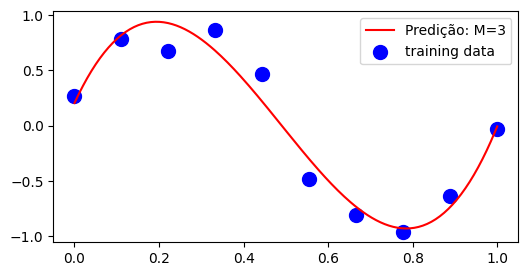

In [59]:
Y_pred = model.predict(Xplot)
fig = plt.figure(figsize=(6, 3))
plt.plot(xplot, Y_pred, label='Predição: M=3', color = 'red')
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b", s=100,
            label="training data")
plt.legend(fontsize=10)
plt.show(True)

Nesse caso, o ajuste reproduz melhor a tendência observada nos dados.

Vamos verificar para um polinômio de grau $M=9$.
$$
f(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_9 x^9
$$


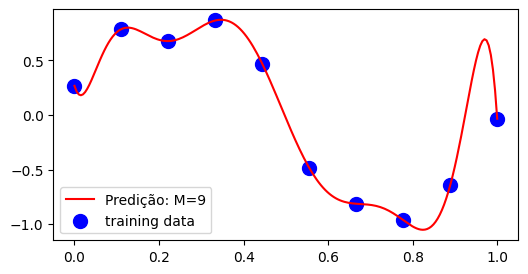

In [60]:
poly9 = PolynomialFeatures(degree=9)
X = poly9.fit_transform(X_train)
model = linear_model.LinearRegression()
model.fit(X,y_train)

Xplot=poly9.fit_transform(xplot)
Y_pred = model.predict(Xplot)
fig = plt.figure(figsize=(6, 3))
plt.plot(xplot, Y_pred, label='Predição: M=9', color = 'red')
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b", s=100,
            label="training data")
plt.legend(fontsize=10)
plt.show(True)

Para um polinômio de grau $M=9$, a curva se ajusta a todos os pontos. Em princícipio, esse parece ser o melhor ajuste. No entanto, essa é uma indicação que o modelo está sobre-ajustado, de modo que consegue predizer o conjunto de treinamento perfeitamente. Ou seja, o modelo está memorizando os dados. Esse é um caso típico de **overfitting**.

Notem ainda que os valores dos coeficientes do modelo são bastante altos, sendo uma outra indicação de overfitting. Esses coeficientes podem ser diminuidos com o uso de regularização, que veremos a seguir.

In [61]:
print("Coeficientes do modelo ajustado:", model.coef_)

Coeficientes do modelo ajustado: [ 0.00000000e+00 -1.28898114e+01  5.66730669e+02 -6.64239852e+03
  3.71710955e+04 -1.14791788e+05  2.05738781e+05 -2.13107899e+05
  1.18357094e+05 -2.72790272e+04]


O ajuste foi feito no conjunto de treinamento. Precisamos agora analisar a capacidade de generalização do modelo. Para isso, vamos fazer a previsão em novos dados, ou seja, no conjunto de teste.

Vamos analisar o erro na predição em função do grau do polinômio. O erro é calculando quando consideramos o conjunto de treinamento e teste, onde obtemos duas curvas distintas.

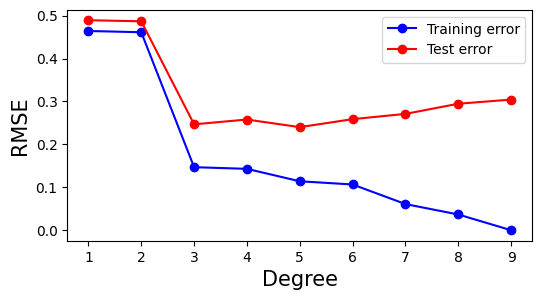

In [62]:
#Funcao para calcular o erro quadrático médio
def rmse(a, b):
    return np.sqrt(np.mean(np.square(a - b)))

# lista que armazena os erros de acordo com o grau do polinomio
training_errors = []
test_errors = []
degree = [] # armazena os graus do polinomio
for M in np.arange(1,10):
    # modelo a ser usado: regressão linear
    model = linear_model.LinearRegression()
    # transforma os dados para obter a matriz onde cada coluna i armazena x**i
    poly = PolynomialFeatures(degree = M)
    X_train_M = poly.fit_transform(X_train)
    # realiza a regressão linear no conjunto de treinamento
    model.fit(X_train_M,y_train)
    y_pred = model.predict(X_train_M)
    error_train = rmse(y_pred,y_train)
    training_errors.append(error_train)

    # realiza a regressão linear no conjunto de teste
    X_test_M = poly.fit_transform(X_test)
    y_pred2 = model.predict(X_test_M)
    error_test = rmse(y_pred2, y_test)
    test_errors.append(error_test)
    degree.append(M)
fig = plt.figure(figsize=(6, 3))
plt.plot(degree, training_errors, 'b-o', label = 'Training error')
plt.plot(degree, test_errors, 'r-o', label= 'Test error')
plt.xlabel("Degree", fontsize = 15)
plt.ylabel("RMSE", fontsize = 15)
plt.legend(fontsize = 10)
plt.show(True)

Notem que o erro na predição, quando usamos o conjunto de teste, tende a aumentar quando aumentamos o grau do polinômio, ou seja, quando aumentamos a complexidade do modelo. Essa é uma indicação de overfitting. Overfitting ocorre quando há um aumento no erro calculado no conjunto de teste, mas há uma alta taxa de acerto no conjunto de treinamento. Notem que o erro no conjunto de treinamento vai a zero quando aumentamos o grau do polinômio. Nesse caso, a curva se ajusta a todos os pontos, como vimos anteriormente para $M = 9$. Em resumo, dizemos que quando ocorre overfitting, o modelo está "memorizando" os dados e não "aprendendo", conforme o esperado.

Se aumentarmos o número de elementos no conjunto de treinamento, reduzimos o overfitting. Ou seja, precisamos balancear a complexidade do modelo de acordo com o volume de dados disponíveis. Vamos gerar os dados como anteriormente, mas com mais pontos.

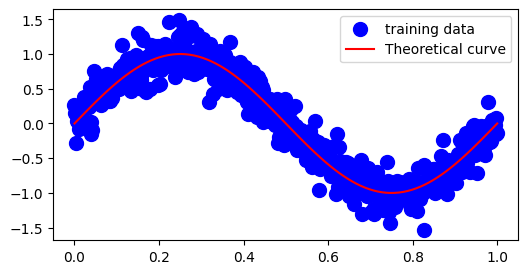

In [63]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(10)

# training set
N_train = 500
sigma = 0.2
x_train= np.linspace(0, 1,N_train)
y_train = function(x_train) + np.random.normal(0,sigma, N_train)
x_train = x_train.reshape(len(x_train), 1)

fig = plt.figure(figsize=(6, 3))
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b",
            s=100, label="training data")

# test set
N_test = 100
x_test=np.linspace(0, 1,N_test)
y_test = function(x_test) +  np.random.normal(0,sigma, N_test)
x_test = x_test.reshape(len(x_test), 1)


# Theoretical curves
xt = np.linspace(0,1,100)
yt = function(xt)
plt.plot(xt,yt, '-r',  label="Theoretical curve")
plt.legend(fontsize=10)
plt.show(True)

Para um polinômio de grau $M=9$, vemos que com mais pontos, overfitting deixa de ocorrer.

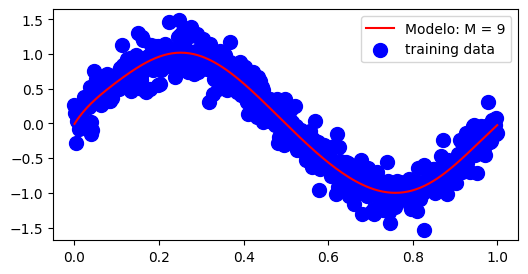

In [64]:
fig = plt.figure(figsize=(6, 3))

poly9 = PolynomialFeatures(degree=9)
X = poly9.fit_transform(x_train)
clf9 = linear_model.LinearRegression()
clf9.fit(X,y_train)

Xplot=poly9.fit_transform(xplot)
Y_pred = clf9.predict(Xplot)
plt.plot(xplot, Y_pred, '-r',  label='Modelo: M = 9')
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b",
            s=100, label="training data")
plt.legend()
plt.show(True)

Além disso, podemos até usar polinômios de grau maior. Analisando o erro em função do grau do polinômio, vemos que ocorre overfitting apenas para polinômios de grau muito alto.

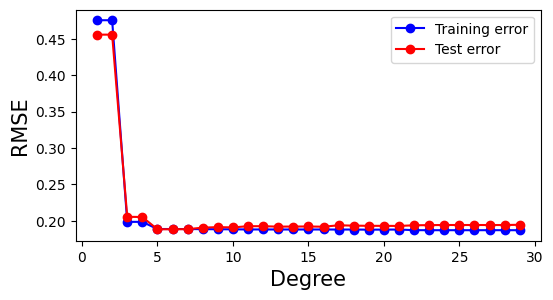

In [65]:
def rmse(a, b):
    return np.sqrt(np.mean(np.square(a - b)))

training_errors = []
test_errors = []
degree = []
for M in np.arange(1,30):
    poly = PolynomialFeatures(degree=M)
    X_train = poly.fit_transform(x_train)
    clf = linear_model.LinearRegression()
    clf.fit(X_train,y_train)
    Y_pred = clf.predict(X_train)
    error_train = rmse(Y_pred,y_train)
    training_errors.append(error_train)

    X_test=poly.fit_transform(x_test)
    Y_pred2 = clf.predict(X_test)
    error_test = rmse(Y_pred2, y_test)
    test_errors.append(error_test)
    degree.append(M)
fig = plt.figure(figsize=(6, 3))
plt.plot(degree, training_errors, 'b-o', label = 'Training error')
plt.plot(degree, test_errors, 'r-o', label= 'Test error')
plt.xlabel("Degree", fontsize = 15)
plt.ylabel("RMSE", fontsize = 15)
plt.legend(fontsize = 10)
plt.show(True)

Ou seja, quanto mais dados estiverem disponíveis, maior pode ser a complexidade do modelo. Temos que ter uma balanço entre complexidade do modelo e dados disponíveis. Esse balanço deve ser levado em conta quando modelos um conjunto de dados.

## Regularização

Vamos gerar os dados novamente.

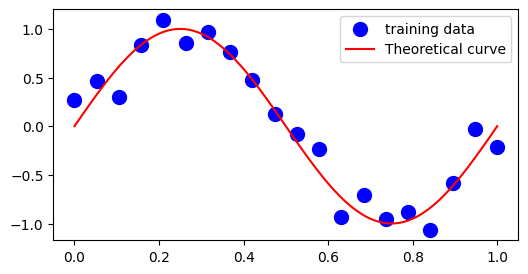

In [66]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(10)

#função para gerar os dados
def function(x):
    y = np.sin(2 * np.pi * x)
    #y = np.cos(2 * np.pi * x)
    #y = x**4 + x**9
    return y

# training set
N_train = 20
sigma = 0.2
x_train= np.linspace(0, 1,N_train)
y_train = function(x_train) + np.random.normal(0,sigma, N_train)
x_train = x_train.reshape(len(x_train), 1)

fig = plt.figure(figsize=(6, 3))
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b",
            s=100, label="training data")

# test set
N_test = 20
x_test=np.linspace(0, 1,N_test)
y_test = function(x_test) +  np.random.normal(0,sigma, N_test)
x_test = x_test.reshape(len(x_test), 1)

# Curva teorica
xt = np.linspace(0,1,100)
yt = function(xt)
plt.plot(xt,yt, '-r',  label="Theoretical curve")
plt.legend(fontsize=10)
plt.show(True)

Usando regularização Lasso, podemos usar um polinômio de grau 9.

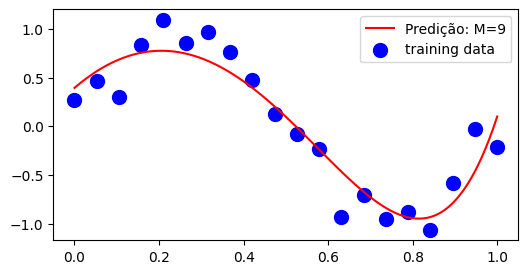

In [67]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

poly9 = PolynomialFeatures(degree=9)
X = poly9.fit_transform(x_train)
model = Lasso(alpha = 0.001)
model.fit(X,y_train)
Xplot=poly9.fit_transform(xplot)
Y_pred = model.predict(Xplot)
fig = plt.figure(figsize=(6, 3))
plt.plot(xplot, Y_pred, label='Predição: M=9', color = 'red')
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b", s=100,
            label="training data")
plt.legend(fontsize=10)
plt.show(True)

Podemos verificar os parâmetros ajustados pelo modelo. Notem que muitos deles são iguais a zero, pois não contribuem para o ajuste. Essa atribuição para serem nulos permite evitar a ocorrência de overfitting.

In [68]:
model.coef_

array([ 0.        ,  3.73098351, -9.14974607, -0.        ,  0.        ,
        2.87700819,  2.24702767,  0.        ,  0.        , -0.        ])

Também podemos usar regularização em uma base de dados. Vamos considerar a regressão linear na base de vendas.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# le os dados
# se for lear do hard disk: ############################
data = pd.read_csv('data/Advertising.csv', header=(0), index_col=[0])

# Se for lear do Google Drive: ############################
#from google.colab import drive
#drive.mount('/content/drive/')

#file_path = '/content/drive/MyDrive/data/Advertising.csv'
#try:
#    data = pd.read_csv(file_path)
#    print(data.head()) # Print the first 5 rows of the DataFrame
#except FileNotFoundError:
#    print(f"Error: The file was not found at {file_path}")
############################

# remove nan (Not a Number)
data = data.dropna()
data = data.drop(data.columns[[0]], axis=1) # remove the first column (if useless)
# define a variável de saída
ylabel = data.columns[-1]
print('Número de observações e atributos:',data.shape)
list_labels = list(data.columns)
data.head(10)

Número de observações e atributos: (200, 3)


,radio,newspaper,sales
1,37.8,69.2,22.1
2,39.3,45.1,10.4
3,45.9,69.3,9.3
4,41.3,58.5,18.5
5,10.8,58.4,12.9
6,48.9,75.0,7.2
7,32.8,23.5,11.8
8,19.6,11.6,13.2
9,2.1,1.0,4.8
10,2.6,21.2,10.6


Convertemos para o formato numpy para facilitar a manipulação.

In [70]:
# Converte os dados para numpy para facilitar a manipulação
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Selecionamos os conjuntos de treinamento e teste.

In [71]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
p = 0.3 # fracao de elementos no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

Ajustamos o modelo de regressão.

In [72]:
from sklearn.linear_model import LinearRegression

# modelo de regressão linear múltipla
lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

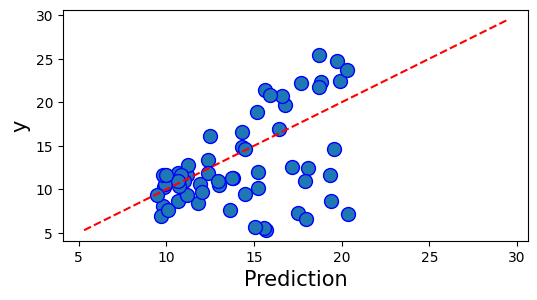

In [73]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(6, 3))
l = plt.plot(y_pred, y_test, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction", fontsize=15)

# mostra os valores preditos e originais
xl = np.arange(min(y_test), 1.2*max(y_test),(max(y_test)-min(y_test))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)

Calculando o coeficiente R2 e o erro:

In [74]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

R2 = r2_score(y_test, y_pred)
print('R2:', R2)

RSME = mean_squared_error(y_test, y_pred)
print("RSME:", RSME)          # Calculate the test MSE

R2: 0.12997792345005088
RSME: 23.755612041549714


### Ridge regression

Vamos considerar dados sobre propaganda em rádio, televisão e jornais. Estamos interessados em determinar se o investimento em propaganda aumenta as vendas e, em caso afirmativo, qual seria o veículo de divulgação mais vantajoso.

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# le os dados
# se for lear do hard disk: ############################
data = pd.read_csv('data/Advertising.csv', header=(0), index_col=[0])

# Se for lear do Google Drive: ############################
#from google.colab import drive
#drive.mount('/content/drive/')

#file_path = '/content/drive/MyDrive/data/Advertising.csv'
#try:
#    data = pd.read_csv(file_path)
#    print(data.head()) # Print the first 5 rows of the DataFrame
#except FileNotFoundError:
#    print(f"Error: The file was not found at {file_path}")
############################

# remove nan (Not a Number)
data = data.dropna()
data = data.drop(data.columns[[0]], axis=1) # remove the first column (if useless)
# define a variável de saída
ylabel = data.columns[-1]

print('Número de observações e atributos:',data.shape)
list_labels = list(data.columns)
data.head(10)

Número de observações e atributos: (200, 3)


,radio,newspaper,sales
1,37.8,69.2,22.1
2,39.3,45.1,10.4
3,45.9,69.3,9.3
4,41.3,58.5,18.5
5,10.8,58.4,12.9
6,48.9,75.0,7.2
7,32.8,23.5,11.8
8,19.6,11.6,13.2
9,2.1,1.0,4.8
10,2.6,21.2,10.6


In [76]:
# Converte os dados para numpy para facilitar a manipulação
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

In [77]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
p = 0.3 # fracao de elementos no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Se aplicarmos a função Ridge com alpha = 0, obtemos o mesmo modelo linear ajustado anteriormente:

In [79]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error

# ajusta o modelo ridge regression
ridge = Ridge(alpha = 0)
ridge.fit(X_train, y_train)             # Fit a ridge regression on the training data
y_pred = ridge.predict(X_test)           # Use this model to predict the test data
RSME = mean_squared_error(y_test, y_pred)
print("RSME:", RSME)          # Calculate the test MSE

from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

RSME: 23.755612041549707
R2: 0.129977923450051


Considerando outro valor de alpha:

In [80]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error

# ajusta o modelo ridge regression
ridge2 = Ridge(alpha = 50)
ridge2.fit(X_train, y_train)             # Fit a ridge regression on the training data
y_pred = ridge2.predict(X_test)           # Use this model to predict the test data
RSME = mean_squared_error(y_test, y_pred)
print("RSME:", RSME)          # Calculate the test MSE

from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

RSME: 23.208987072881545
R2: 0.14999743671297683


Podemos mostrar a predição e os valores originais.

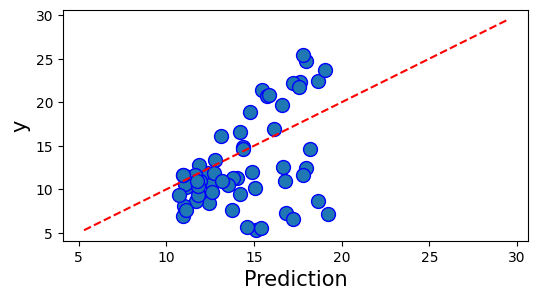

In [81]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(6, 3))
l = plt.plot(y_pred, y_test, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction", fontsize=15)

# mostra os valores preditos e originais
xl = np.arange(min(y_test), 1.2*max(y_test),(max(y_test)-min(y_test))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)

No modelo ridge regression, temos que o parâmetro $\alpha > 0$. Vamos analisar como o coeficiente R2 varia de acordo com $\alpha$.

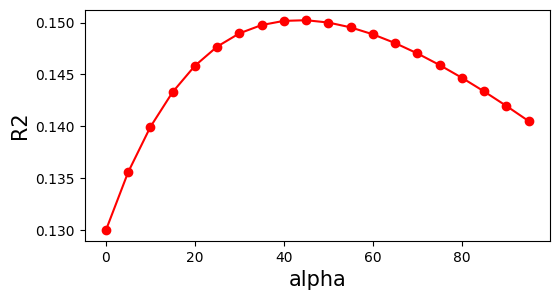

In [82]:
fig = plt.figure(figsize=(6, 3))

vR2 = []
valpha = []
# variamos os valaores de alpha
for alpha in np.arange(0,100,5):
    ridge2 = Ridge(alpha = alpha)
    ridge2.fit(X_train, y_train)             # Fit a ridge regression on the training data
    y_pred = ridge2.predict(X_test)           # Use this model to predict the test data
    r2 = r2_score(y_test, y_pred)
    vR2.append(r2)
    valpha.append(alpha)
plt.plot(valpha, vR2, '-ro')
plt.xlabel("alpha", fontsize=15)
plt.ylabel("R2", fontsize=15)
plt.show(True)

Para $\alpha > 0$, o coeficiente R2 diminui, indicando que o ajuste tradicional, para $\alpha = 0$, resulta em um resultado melhor.

Ou seja, para esse conjunto de dados, a melhor opção é considerar a regressão linear simples.

### LASSO

Usando os dados anteriores, vamos aplicar o método Lasso (least absolute shrinkage and selection operator) aos dados.

In [83]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alpha = 1
# notice that we need to normalize the attributes: normalize = True
lasso = Lasso(alpha=alpha)
lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
y_pred = lasso.predict(X_test)           # Use this model to predict the test data

RSME = mean_squared_error(y_test, y_pred)
print("RSME:", RSME)          # Calculate the test MSE

from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

RSME: 23.196807994338464
R2: 0.15044348151224307


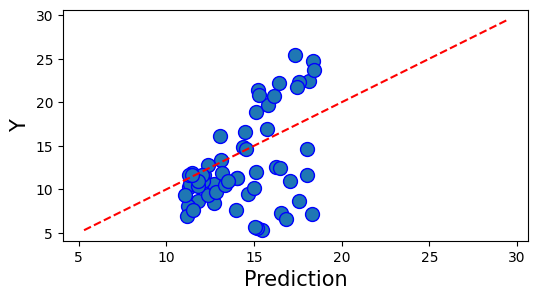

In [84]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 3))
l = plt.plot(y_pred, y_test, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("Y", fontsize=15)
plt.xlabel("Prediction", fontsize=15)

xl = np.arange(min(y_test), 1.2*max(y_test),(max(y_test)-min(y_test))/10)
yl = xl
plt.plot(xl, yl, 'r--')

#plt.grid(True)
plt.show(True)

Variando alpha, vemos que o coeficiente R2 diminui ainda mais.

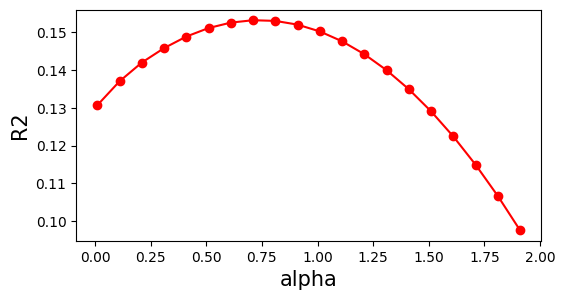

In [85]:
fig = plt.figure(figsize=(6, 3))

vR2 = []
valpha = []
for alpha in np.arange(0.01,2,0.1):
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
    y_pred = lasso.predict(X_test)           # Use this model to predict the test data
    r2 = r2_score(y_test, y_pred)
    vR2.append(r2)
    valpha.append(alpha)
plt.plot(valpha, vR2, '-ro')
plt.xlabel("alpha", fontsize=15)
plt.ylabel("R2", fontsize=15)
plt.show(True)

No método Lasso, podemos calcular os coeficientes de modo a selecionar os atributos mais importantes. Se algum atributo apresentar os respectivo coeficiente igual a zero, então esse atributo não contribui para a regressão.

In [86]:
lasso = Lasso(alpha = 0.2)
lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
print('Coeficientes: TV, radio, newspaper')
lasso.coef_

Coeficientes: TV, radio, newspaper


array([2.98496528, 0.03708156])

Ou seja, vemos que a variável newspaper recebeu peso igual a zero, indicando que não é importante na predição. Portanto, não vale a pena investir em anúncios em jornais, pois o ganho nas vendas pode ser obtido com investimentos em TV e radio.

## Overfitting e underfitting em dados

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import seaborn as sns

# le os dados
# se for lear do hard disk: ############################
data = pd.read_csv('data/Vehicle.csv', header=(0), index_col=[0])

# Se for lear do Google Drive: ############################
#from google.colab import drive
#drive.mount('/content/drive/')

#file_path = '/content/drive/MyDrive/data/Vehicle.csv'
#try:
#    data = pd.read_csv(file_path)
#    print(data.head()) # Print the first 5 rows of the DataFrame
#except FileNotFoundError:
#    print(f"Error: The file was not found at {file_path}")
############################

# remove nan (Not a Number)
data = data.dropna()

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Vamos criar a curva de aprendizado para um caso em que não há overfitting.

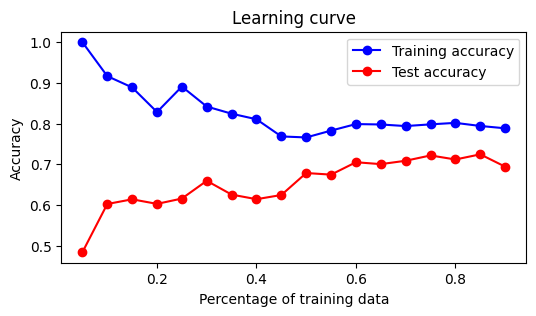

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

vp = np.arange(0.05,0.95,0.05)
vacc_train = []
vacc_test = []
for p in vp:
  X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)
  # Cria o modelo usando o criterio Gini
  model = tree.DecisionTreeClassifier(criterion = 'gini',
                                      random_state = 101, max_depth = 5)
  # Ajusta o modelo usando os dados de treinamento
  model.fit(X_train,y_train)
  # realizar a predição no treinamento
  y_pred_train = model.predict(X_train)
  score_train = accuracy_score(y_pred_train, y_train)
  vacc_train.append(score_train)

    # realizar a predição no teste
  y_pred = model.predict(X_test)
  score_test = accuracy_score(y_pred, y_test)
  vacc_test.append(score_test)

fig = plt.figure(figsize=(6, 3))
plt.plot(vp, vacc_train, 'b-o', label = 'Training accuracy')
plt.plot(vp, vacc_test, 'r-o', label= 'Test accuracy')
plt.xlabel("Percentage of training data", fontsize = 10)
plt.ylabel("Accuracy", fontsize = 10)
plt.legend(fontsize = 10)
plt.title('Learning curve')
plt.show(True)

Se aumentarmos o tamanho da árvore, vamos ter overfitting.

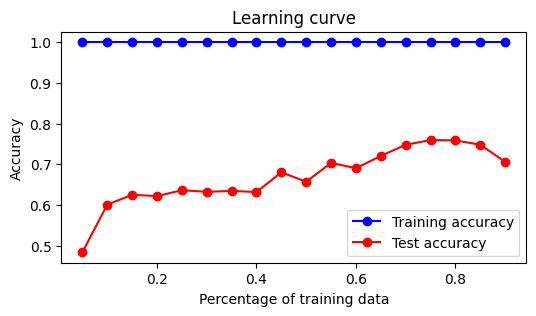

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

vp = np.arange(0.05,0.95,0.05)
vacc_train = []
vacc_test = []
for p in vp:
  X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)
  # Cria o modelo usando o criterio Gini
  model = tree.DecisionTreeClassifier(criterion = 'gini',
                                      random_state = 101,
                                      max_depth = 150)
  # Ajusta o modelo usando os dados de treinamento
  model.fit(X_train,y_train)
  # realizar a predição no treinamento
  y_pred_train = model.predict(X_train)
  score_train = accuracy_score(y_pred_train, y_train)
  vacc_train.append(score_train)

    # realizar a predição no teste
  y_pred = model.predict(X_test)
  score_test = accuracy_score(y_pred, y_test)
  vacc_test.append(score_test)

fig = plt.figure(figsize=(6, 3))
plt.plot(vp, vacc_train, 'b-o', label = 'Training accuracy')
plt.plot(vp, vacc_test, 'r-o', label= 'Test accuracy')
plt.xlabel("Percentage of training data", fontsize = 10)
plt.ylabel("Accuracy", fontsize = 10)
plt.legend(fontsize = 10)
plt.title('Learning curve')
plt.show(True)

Podemos também observar underfitting se a árvore for muito pequena.

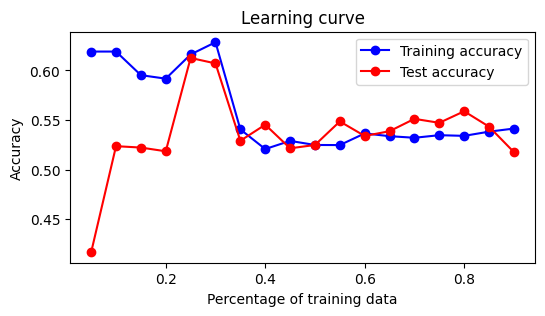

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

vp = np.arange(0.05,0.95,0.05)
vacc_train = []
vacc_test = []
for p in vp:
  X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)
  # Cria o modelo usando o criterio Gini
  model = tree.DecisionTreeClassifier(criterion = 'gini',
                                      random_state = 101,
                                      max_depth = 2)
  # Ajusta o modelo usando os dados de treinamento
  model.fit(X_train,y_train)
  # realizar a predição no treinamento
  y_pred_train = model.predict(X_train)
  score_train = accuracy_score(y_pred_train, y_train)
  vacc_train.append(score_train)

    # realizar a predição no teste
  y_pred = model.predict(X_test)
  score_test = accuracy_score(y_pred, y_test)
  vacc_test.append(score_test)

fig = plt.figure(figsize=(6, 3))
plt.plot(vp, vacc_train, 'b-o', label = 'Training accuracy')
plt.plot(vp, vacc_test, 'r-o', label= 'Test accuracy')
plt.xlabel("Percentage of training data", fontsize = 10)
plt.ylabel("Accuracy", fontsize = 10)
plt.legend(fontsize = 10)
plt.title('Learning curve')
plt.show(True)

Veja mais nesse link:<br>
https://www.geeksforgeeks.org/machine-learning/how-to-identify-overfitting-machine-learning-models-in-scikit-learn/

## Exercícios para entregar

#### 1 - Considere a base de concreto da UCI. Ajuste um modelo de regressão para predizer a variável y (Concrete compressive strength). Compare o coeficiente R2 obtido através de regressão linear múltipla, Lasso e ridge regression. Para os métodos Lasso e ridge regression, faça um gráfico de $\alpha \times$ R2 como foi feito nos exemplos anteriores. Use o código a seguir.

In [91]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets.squeeze()

# To combine them into a single pandas DataFrame
#df = pd.concat([X, y], axis=1)


# metadata
print(concrete_compressive_strength.metadata)

# variable information
print(concrete_compressive_strength.variables)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeli

In [92]:
from sklearn.linear_model import LinearRegression

#Dividindo entre train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


#chamdno o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)


#predizendo y
y_pred = modelo.predict(X_test)



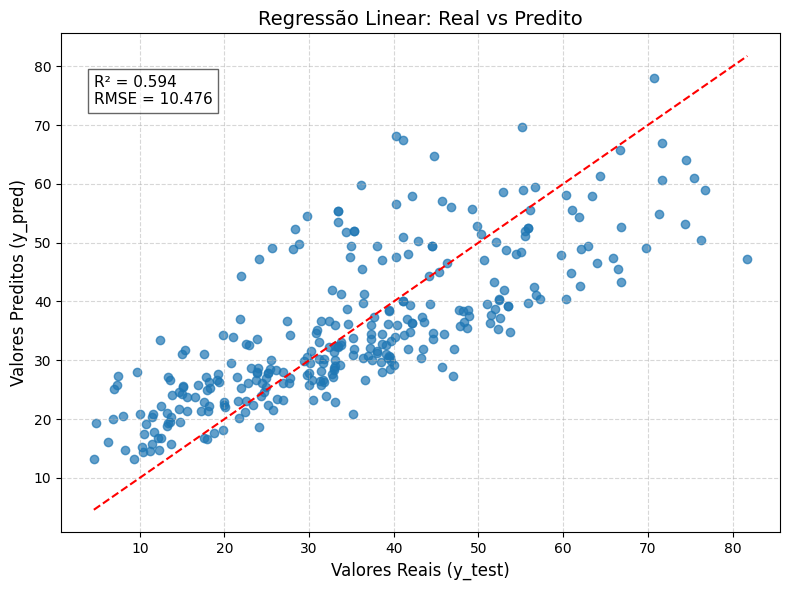

In [93]:

# métricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# figura
plt.figure(figsize=(8, 6))

# scatter (real vs previsto)
plt.scatter(y_test, y_pred, alpha=0.7)

# linha ideal (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

# labels e título
plt.xlabel("Valores Reais (y_test)", fontsize=12)
plt.ylabel("Valores Preditos (y_pred)", fontsize=12)
plt.title("Regressão Linear: Real vs Predito", fontsize=14)

# métricas no gráfico
plt.text(min_val, max_val*0.9,
         f"R² = {r2:.3f}\nRMSE = {rmse:.3f}",
         fontsize=11,
         bbox=dict(facecolor='white', alpha=0.6))

# grid ajuda muito na leitura
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

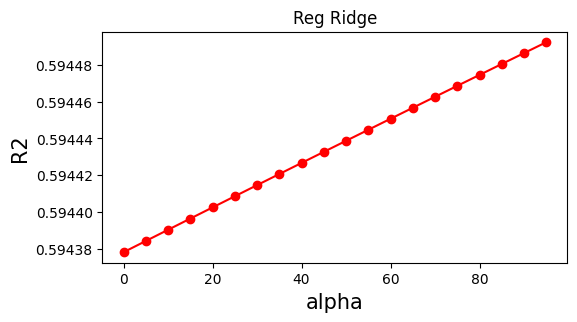

In [94]:
fig = plt.figure(figsize=(6, 3))

vR2 = []
valpha = []
# variamos os valaores de alpha
for alpha in np.arange(0,100,5):
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train, y_train)             # Fit a ridge regression on the training data
    y_pred = ridge.predict(X_test)           # Use this model to predict the test data
    r2 = r2_score(y_test, y_pred)
    vR2.append(r2)
    valpha.append(alpha)
plt.plot(valpha, vR2, '-ro')
plt.title("Reg Ridge")
plt.xlabel("alpha", fontsize=15)
plt.ylabel("R2", fontsize=15)
plt.show(True)

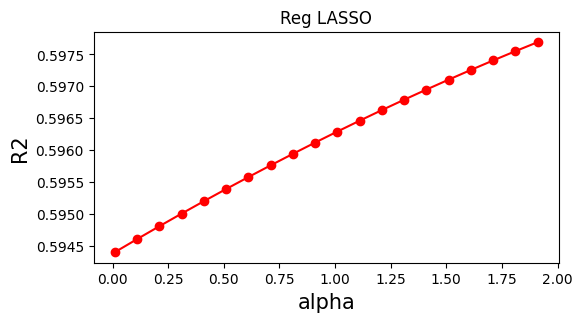

In [95]:
#Lasso
fig = plt.figure(figsize=(6, 3))

vR2 = []
valpha = []
for alpha in np.arange(0.01,2,0.1):
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
    y_pred = lasso.predict(X_test)           # Use this model to predict the test data
    r2 = r2_score(y_test, y_pred)
    vR2.append(r2)
    valpha.append(alpha)
plt.plot(valpha, vR2, '-ro')
plt.title("Reg LASSO")
plt.xlabel("alpha", fontsize=15)
plt.ylabel("R2", fontsize=15)
plt.show(True)

#### 2 - Determine as variáveis que mais influenciam a variável y (Concrete compressive strength).

Ao aplicar o Lasso, podemos encontrar e selecionar os atributos mais importantes. Onde, se ele for igual a zero então este nao contribui para a regressão.

In [96]:
feature_names = concrete_compressive_strength.data.features.columns.tolist()
print(feature_names)

['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


In [97]:
lasso = Lasso(alpha = 2.0)
lasso.fit(X_train, y_train)             # Fit a ridge regression on the training data
print(f'Coeficientes:{feature_names}')
lasso.coef_

Coeficientes:['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


array([ 0.12274433,  0.11322053,  0.08807651, -0.12280313,  0.27006222,
        0.02109894,  0.03116489,  0.11299886])

Analisando os resultados, podemos ver que os atributos cement, blast furnace slag, Superplasticizer e age são as mais importantes para a regressão.

#### 3 - Considere os dados gerados com o código a seguir. Usando regularização, ajuste o grau do polinômio que define o modelo mais adequado.

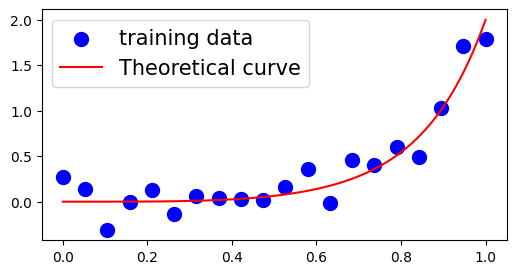

In [98]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(10)

#função para gerar os dados
def function(x):
    y = x**4 + x**9
    return y

# training set
N_train = 20 #numero de amostras
sigma = 0.2
x_train= np.linspace(0, 1,N_train)
y_train = function(x_train) + np.random.normal(0,sigma, N_train)
x_train = x_train.reshape(len(x_train), 1)

fig = plt.figure(figsize=(6, 3))
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b",
            s=100, label="training data")

# test set
N_test = 20 #numero de amostras
x_test=np.linspace(0, 1,N_test)
y_test = function(x_test) +  np.random.normal(0,sigma, N_test)
x_test = x_test.reshape(len(x_test), 1)

# Curva teorica
xt = np.linspace(0,1,100)
yt = function(xt)
plt.plot(xt,yt, '-r',  label="Theoretical curve")
plt.legend(fontsize=15)
plt.show(True)

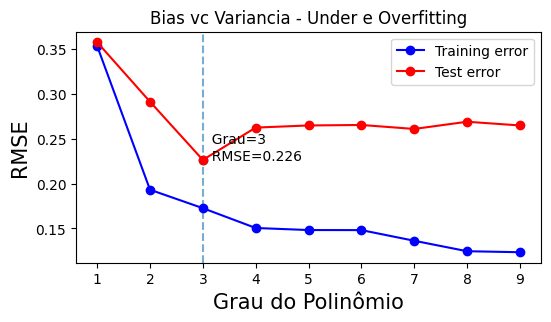

<Figure size 640x480 with 0 Axes>

In [99]:
#Funcao para calcular o erro quadrático médio
def rmse(a, b):
    return np.sqrt(np.mean(np.square(a - b)))

# lista que armazena os erros de acordo com o grau do polinomio
training_errors = []
test_errors = []
degree = [] # armazena os graus do polinomio
for M in np.arange(1,10):
    # modelo a ser usado: regressão linear
    model = linear_model.LinearRegression()
    # transforma os dados para obter a matriz onde cada coluna i armazena x**i
    poly = PolynomialFeatures(degree = M)
    X_train_M = poly.fit_transform(x_train)
    # realiza a regressão linear no conjunto de treinamento
    model.fit(X_train_M,y_train)
    y_pred = model.predict(X_train_M)
    error_train = rmse(y_pred,y_train)
    training_errors.append(error_train)

    # realiza a regressão linear no conjunto de teste
    X_test_M = poly.fit_transform(x_test)
    y_pred2 = model.predict(X_test_M)
    error_test = rmse(y_pred2, y_test)
    test_errors.append(error_test)
    degree.append(M)

# melhor grau (menor erro de teste)
best_idx = np.argmin(test_errors)
best_degree = degree[best_idx]
best_error = test_errors[best_idx]



fig = plt.figure(figsize=(6, 3))
plt.axvline(best_degree, linestyle='--', alpha=0.6)
plt.scatter(best_degree, best_error)

plt.text(best_degree, best_error,
         f'  Grau={best_degree}\n  RMSE={best_error:.3f}',
         fontsize=10)

plt.plot(degree, training_errors, 'b-o', label = 'Training error')
plt.plot(degree, test_errors, 'r-o', label= 'Test error')
plt.xlabel("Grau do Polinômio", fontsize = 15)
plt.ylabel("RMSE", fontsize = 15)
plt.title("Bias vc Variancia - Under e Overfitting")
plt.legend(fontsize = 10)
plt.show(True)
plt.tight_layout()



Analisando o grafico, percebe-se que o melhor grau do modelo para o conjunto de dados é um modelo de grau 3.

Aplicando ridge

In [100]:

training_errors = []
test_errors = []
degree = []

for M in np.arange(1,10):
    
    poly = PolynomialFeatures(degree=M)
    
    X_train_M = poly.fit_transform(x_train)
    X_test_M = poly.transform(x_test)
    
    model = Ridge(alpha=0.01)  #regularização com RIdge
    model.fit(X_train_M, y_train)
    
    y_pred = model.predict(X_train_M)
    y_pred2 = model.predict(X_test_M)
    
    training_errors.append(rmse(y_pred, y_train))
    test_errors.append(rmse(y_pred2, y_test))
    
    degree.append(M)

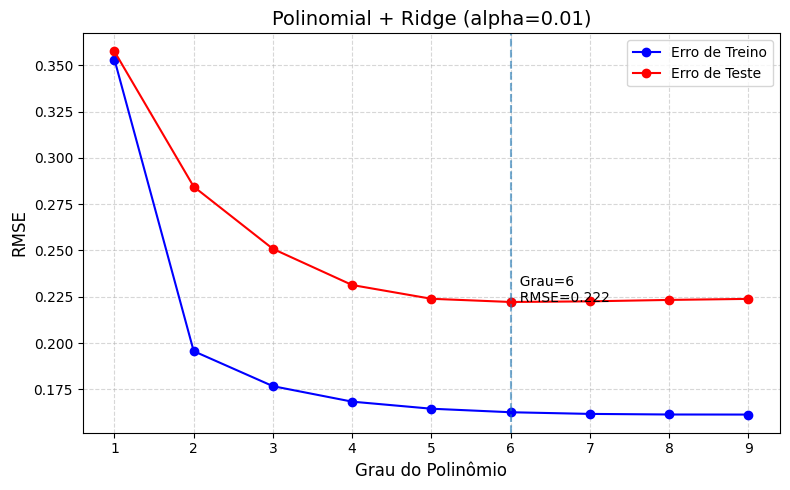

In [101]:
plt.figure(figsize=(8,5))

plt.plot(degree, training_errors, 'b-o', label='Erro de Treino')
plt.plot(degree, test_errors, 'r-o', label='Erro de Teste')

# melhor grau (menor erro de teste)
best_idx = np.argmin(test_errors)
best_degree = degree[best_idx]
best_error = test_errors[best_idx]

# destaque visual
plt.axvline(best_degree, linestyle='--', alpha=0.6)
plt.scatter(best_degree, best_error)

plt.text(best_degree, best_error,
         f'  Grau={best_degree}\n  RMSE={best_error:.3f}',
         fontsize=10)

plt.xlabel("Grau do Polinômio", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title("Polinomial + Ridge (alpha=0.01)", fontsize=14)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

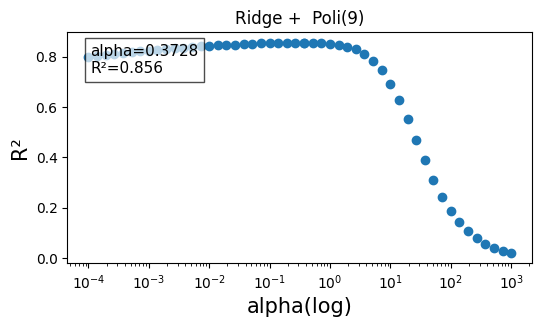

In [106]:
fig = plt.figure(figsize=(6, 3))

vR2 = []
valpha = []
alphas = np.logspace(-4,3,50)
# variamos os valaores de alpha
for alpha in alphas:
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train_M, y_train)  
            
    y_pred = ridge.predict(X_test_M)          
    r2 = r2_score(y_test, y_pred)

    vR2.append(r2)
    valpha.append(alpha)

best_idx = np.argmax(vR2)
best_alpha = valpha[best_idx]
best_r2 = vR2[best_idx]

plt.plot(valpha, vR2, 'o')
plt.xscale('log')

plt.scatter(best_alpha, best_r2)
plt.text(0.05, 0.95,
         f'alpha={best_alpha:.4f}\nR²={best_r2:.3f}',
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))
plt.title("Ridge +  Poli(9)")
plt.xlabel("alpha(log)", fontsize=15)
plt.ylabel("R²", fontsize=15)
plt.show(True)